# Calibrate DiscFac for the Habit+Portfolio Model

The Habit+Portfolio model gives agents access to the equity premium, which
raises expected returns and thus increases wealth accumulation relative to the
habit-only (risk-free) model.  For an apples-to-apples comparison of the two
models, we want them to produce approximately the same mean wealth at
retirement.  We hold CRRA fixed and search over `DiscFac` for the portfolio
model until its mean wealth at the brink of retirement matches the habit-only
model's.

In [1]:
import numpy as np
from HARK.ConsumptionSaving.ConsHabitPortfolioModel import HabitPortfolioConsumerType
from HARK.ConsumptionSaving.ConsHabitModel import HabitConsumerType
from HARK.Calibration.life_tables.us_ssa.SSATools import parse_ssa_life_table

In [2]:
# --- Shared lifecycle parameters (identical to the main notebook) ---
LivPrb_SSA = parse_ssa_life_table(age_min=22, age_max=95, female=False, cohort=1960)

ReplRate = (0.6821 + 0.9389) / 2
PermGroFac_LC = [1.03] * 43 + [ReplRate] + [1.0] * 29

LC_params = dict(
    cycles=1,
    T_cycle=73,
    PermGroFac=PermGroFac_LC,
    LivPrb=LivPrb_SSA,
    Rfree=[1.03] * 73,
    PermShkStd=[0.1] * 73,
    TranShkStd=[0.1] * 73,
    CRRA=5.0,
    RiskyAvg=1.05,
    HabitWgt=0.5,
    HabitRte=0.2,
    AgentCount=5000,
    T_age=73,
)

# Retirement starts at age 65 = period 43.  We target wealth at the end of
# the last working period (period 42, age 64).
retirement_period = 43
target_period = retirement_period - 1  # period 42, age 64

## Step 1: Compute the habit-only target wealth

In [3]:
habit_params = {
    k: v
    for k, v in LC_params.items()
    if k not in ["RiskyAvg", "RiskyStd", "RiskyCount", "ShareCount"]
}

Htype = HabitConsumerType(**habit_params)
Htype.solve()
Htype.T_sim = 73
Htype.initialize_sym(stop_dead=False)
Htype.symulate()

# Wealth in levels = aNrm * pLvl at the target period
W_habit = np.mean(
    Htype.hystory["aNrm"][target_period] * Htype.hystory["pLvl"][target_period]
)
print("Habit-only model (DiscFac = 0.96):")
print(f"  Mean wealth at age 64 (period {target_period}): {W_habit:.4f}")

Habit-only model (DiscFac = 0.96):
  Mean wealth at age 64 (period 42): 9.9626


## Step 2: Bisect on DiscFac for the Habit+Portfolio model

In [4]:
def portfolio_wealth_at_retirement(disc_fac):
    """Solve and simulate the Habit+Portfolio model with a given DiscFac,
    return mean wealth at the target period."""
    params = dict(LC_params, DiscFac=disc_fac)
    agent = HabitPortfolioConsumerType(**params)
    agent.solve()
    agent.T_sim = 73
    agent.initialize_sym(stop_dead=False)
    agent.symulate()
    W = np.mean(
        agent.hystory["aNrm"][target_period] * agent.hystory["pLvl"][target_period]
    )
    return W


# Bisection search
lo, hi = 0.80, 0.96
tol = 0.005  # match within 0.5% of target wealth
max_iter = 20

print(f"Target wealth (habit-only): {W_habit:.4f}")
print(f"{'Iter':>4s}  {'DiscFac':>8s}  {'W_port':>10s}  {'Gap':>10s}  {'Gap%':>8s}")
print("-" * 50)

for i in range(max_iter):
    mid = (lo + hi) / 2
    W_port = portfolio_wealth_at_retirement(mid)
    gap = W_port - W_habit
    gap_pct = 100 * gap / W_habit
    print(f"{i:4d}  {mid:8.5f}  {W_port:10.4f}  {gap:+10.4f}  {gap_pct:+8.2f}%")

    if abs(gap_pct) < 0.5:
        print(f"\nConverged! DiscFac = {mid:.5f}")
        break

    if W_port > W_habit:
        hi = mid  # too wealthy -> lower patience
    else:
        lo = mid  # too poor -> raise patience
else:
    print(f"\nDid not converge after {max_iter} iterations.")
    print(f"Best DiscFac = {mid:.5f}, gap = {gap_pct:+.2f}%")

DiscFac_calibrated = mid
print(f"\n==> Use DiscFac = {DiscFac_calibrated:.5f} in the Habit+Portfolio model")

Target wealth (habit-only): 9.9626
Iter   DiscFac      W_port         Gap      Gap%
--------------------------------------------------
   0   0.88000     18.2896     +8.3271    +83.58%
   1   0.84000      8.2832     -1.6794    -16.86%
   2   0.86000     12.1754     +2.2128    +22.21%
   3   0.85000     10.2076     +0.2450     +2.46%
   4   0.84500      9.3550     -0.6075     -6.10%
   5   0.84750      9.5538     -0.4088     -4.10%
   6   0.84875      9.4022     -0.5603     -5.62%
   7   0.84938     10.0316     +0.0690     +0.69%
   8   0.84906     10.0661     +0.1036     +1.04%
   9   0.84891     10.2162     +0.2536     +2.55%
  10   0.84883      9.9621     -0.0004     -0.00%

Converged! DiscFac = 0.84883

==> Use DiscFac = 0.84883 in the Habit+Portfolio model


## Step 3: Verify — compare lifecycle wealth profiles

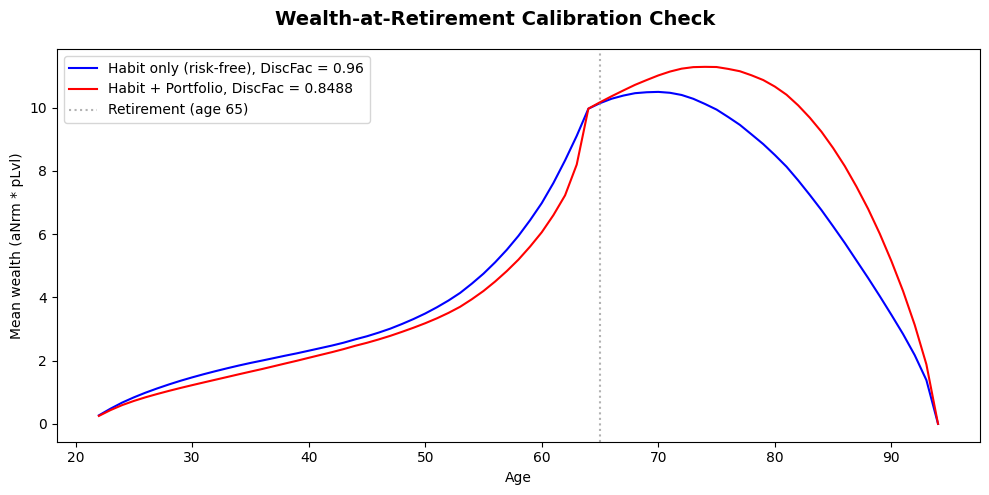


Wealth at age 64:
  Habit only:       9.9626
  Habit + Portfolio: 9.9653
  Ratio:            1.0003


In [5]:
import matplotlib.pyplot as plt

# Re-simulate habit+portfolio with calibrated DiscFac
HPtype = HabitPortfolioConsumerType(**dict(LC_params, DiscFac=DiscFac_calibrated))
HPtype.solve()
HPtype.T_sim = 73
HPtype.initialize_sym(stop_dead=False)
HPtype.symulate()

age_vec = np.arange(22, 95)
W_hp = np.mean(HPtype.hystory["aNrm"] * HPtype.hystory["pLvl"], axis=1)
W_h = np.mean(Htype.hystory["aNrm"] * Htype.hystory["pLvl"], axis=1)

fig, ax = plt.subplots(figsize=(10, 5))
fig.suptitle("Wealth-at-Retirement Calibration Check", fontsize=14, fontweight="bold")
ax.plot(age_vec, W_h, "-b", label="Habit only (risk-free), DiscFac = 0.96")
ax.plot(
    age_vec, W_hp, "-r", label=f"Habit + Portfolio, DiscFac = {DiscFac_calibrated:.4f}"
)
ax.axvline(65, color="gray", ls=":", alpha=0.6, label="Retirement (age 65)")
ax.set_xlabel("Age")
ax.set_ylabel("Mean wealth (aNrm * pLvl)")
ax.legend()
plt.tight_layout()
plt.show()

print("\nWealth at age 64:")
print(f"  Habit only:       {W_h[target_period]:.4f}")
print(f"  Habit + Portfolio: {W_hp[target_period]:.4f}")
print(f"  Ratio:            {W_hp[target_period] / W_h[target_period]:.4f}")